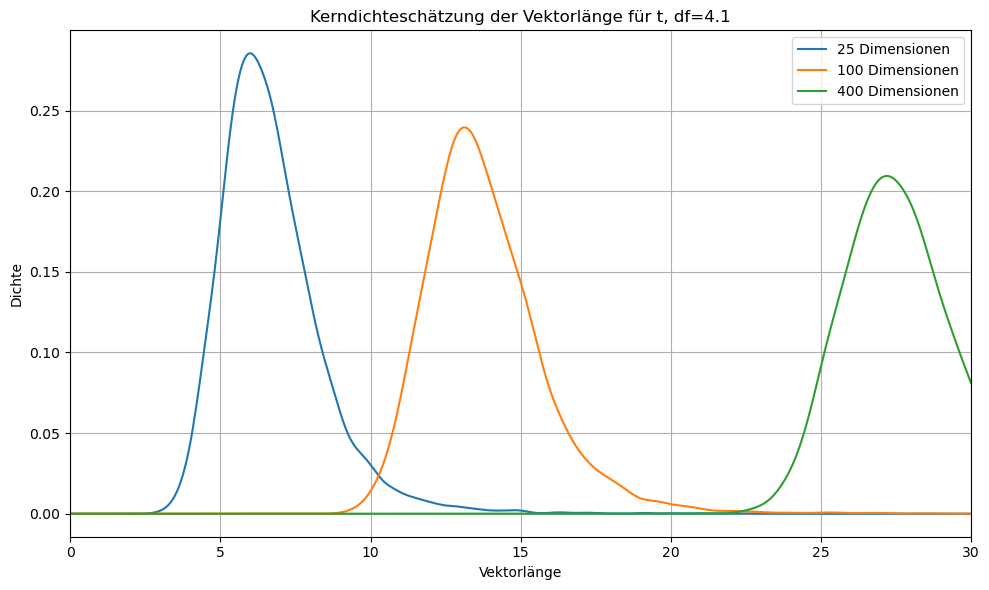

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

# Verfügbare Verteilungen
distributions = {
    'N(0,1)': stats.norm(),
    'Exp(1)': stats.expon(),
    't, df=2.1': stats.t(df=2.1),
    't, df=3.1': stats.t(df=3.1),
    't, df=4.1': stats.t(df=4.1)
}

# Einstellungen
chosen_distribution = 't, df=4.1'
dims_to_test = [25, 100, 400]
n_samples = 10000

# Hole Verteilung
dist = distributions[chosen_distribution]

# Finde maximale x-Achse aus allen Dimensionen
x_max = np.sqrt(max(dims_to_test)) + 10

# Zeichnen
plt.figure(figsize=(10, 6))

for k in dims_to_test:
    samples = dist.rvs(size=(n_samples, k))
    norms = np.linalg.norm(samples, axis=1)

    kde = gaussian_kde(norms)
    x_grid = np.linspace(0, x_max, 500)
    y_vals = kde(x_grid)

    plt.plot(x_grid, y_vals, label=f'{k} Dimensionen')

# Achsenbeschriftung und Anzeige
plt.title(f'Kerndichteschätzung der Vektorlänge für {chosen_distribution}')
plt.xlabel('Vektorlänge')
plt.ylabel('Dichte')
plt.xlim(0, x_max)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
